In [1]:
from asynctorch.nn.architecture.mixed_architecture import AsyncNetwork, MixedArchitecture
from asynctorch.nn.neuron.lif_state import LIFFunction, LIFState
import torch
import numpy as np
import time
from torch import nn
import torch.nn.functional as F
from asynctorch.utils.surrogate import FastSigmoid
import matplotlib.pyplot as plt
from math import prod
from snntorch import surrogate
device = torch.device("cuda")

def drop_smallest_fraction_abs(tensor, fraction):
    """
    Drop the smallest `percent` of absolute values in the tensor.

    Args:
    - tensor (torch.Tensor): The input tensor.
    - fraction (float): The fraction of smallest absolute values to drop.

    Returns:
    - torch.Tensor: The tensor with the smallest `percent` of absolute values set to zero.
    """
    # Flatten the tensor
    flat_tensor = tensor.flatten()

    # Calculate the absolute values
    abs_tensor = torch.abs(flat_tensor)

    # Sort the absolute values
    sorted_abs_tensor, _ = torch.sort(abs_tensor)

    # Find the cutoff index for the top (100-percent)%
    cutoff_index = int(fraction * len(sorted_abs_tensor))

    # Get the cutoff value
    cutoff_value = sorted_abs_tensor[cutoff_index]

    # Create a mask for values greater than the cutoff value (based on absolute values)
    mask = abs_tensor >= cutoff_value

    return mask.view_as(tensor).float()

In [2]:
n_outputs = 10
input_shape = (2, 34, 34)
layer1_shape = (8, 16, 16)
layer2_shape = (16, 8, 8)
layer3_shape = (32, 4, 4)
module_per_layer = [nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=0).to(device), 
                    nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1).to(device), 
                    nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1).to(device),
                    nn.Linear(prod(layer3_shape), n_outputs).to(device)]
shape_per_layer = [input_shape, layer1_shape, layer2_shape, (prod(layer3_shape), ), (n_outputs, )]
neurons_per_layer = [prod(layer1_shape), prod(layer2_shape), prod(layer3_shape), n_outputs]
n_neurons = sum(neurons_per_layer)

In [3]:
n_outputs = 10
input_shape = (2, 34, 34)
layer1_shape = (64, )
layer2_shape = (64, )
layer3_shape = (64, )
module_per_layer = [nn.Linear(prod(input_shape), prod(layer1_shape), bias=False).to(device),
                    nn.Linear(prod(layer1_shape), prod(layer2_shape), bias=False).to(device),
                    nn.Linear(prod(layer2_shape), prod(layer3_shape), bias=False).to(device),
                    nn.Linear(prod(layer3_shape), n_outputs, bias=False).to(device)]
shape_per_layer = [(prod(input_shape), ), layer1_shape, layer2_shape, layer3_shape, (n_outputs, )]
neurons_per_layer = [prod(layer1_shape), prod(layer2_shape), prod(layer3_shape), n_outputs]
n_neurons = sum(neurons_per_layer)

In [4]:
# Prepare state module
n_input_spikes = 8
n_forward_steps = 1
tau_m = 0.9
membrane_threshold = 0.3
sync_threshold = 0.0
spike_grad = FastSigmoid(1)# surrogate.fast_sigmoid(1)# FastSigmoid(1)
sync_grad = FastSigmoid(1)# surrogate.fast_sigmoid(1)#
batch_size = 2
state_module = LIFState(neurons_per_layer, tau_m, membrane_threshold, 
                        sync_threshold, spike_grad, sync_grad, device, 
                        backprop_threshold=-0.3)
state_module._init_state(batch_size)
torch.manual_seed(0)
torch.cuda.reset_peak_memory_stats()
network = AsyncNetwork.build_sequential(module_per_layer, shape_per_layer)
forward_module = MixedArchitecture(network, device)
# Forward pass
s = torch.zeros((batch_size, n_neurons), dtype=torch.float32, device=device)
s[:, torch.randperm(n_neurons)[:n_input_spikes]] = 1
t = time.time()
for i in range(n_forward_steps):
    I_new, n_I_new = forward_module(s, False, False)
    #with torch.no_grad():
    #    mask = drop_smallest_fraction_abs(I_new, 0.9)
    #I_new = I_new * mask
    #n_I_new = n_I_new * mask
    #print('I density: ', I_new.count_nonzero() / I_new.numel())
    s_new = state_module(I_new, n_I_new)
    s = s + s_new
print('Forward time: ', time.time() - t)
# Backward pass
t = time.time()
s.sum().backward()
print('Backward time: ', time.time() - t)
# Print memory usage
print('Memory: ', torch.cuda.max_memory_allocated() / 1e3, 'KB')

Forward time:  0.05276131629943848
Backward time:  0.019037485122680664
Memory:  17721.856 KB


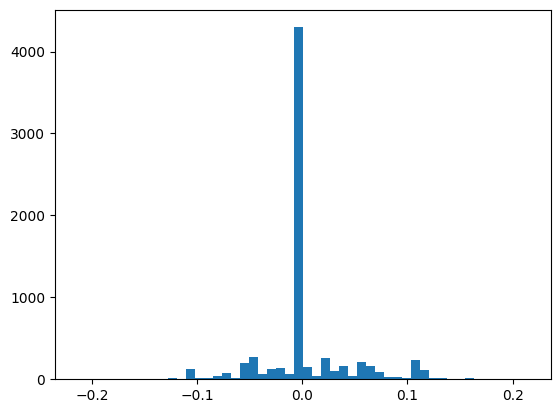

In [5]:
plt.hist(I_new.cpu().detach().numpy().flatten(), bins=50);